# Medical Insurance Cost Prediction

A beginner-friendly, portfolio-ready machine learning project that predicts medical insurance charges using a Decision Tree Regressor.

## 1. Problem Statement

Medical insurance charges vary widely across individuals because of factors such as age, smoking status, BMI, and region. The goal of this project is to build a predictive model that estimates insurance charges and to explain the model in an educational way.

## 2. Project Objective

The main objective is to build a reliable regression model that predicts insurance charges and to understand which variables influence the prediction the most. This notebook is designed to be clear for beginners while still following a professional machine learning workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 3. Load Dataset

The dataset is loaded from a local CSV file. It contains demographic and lifestyle information along with insurance charges, which makes it suitable for a supervised regression task.

In [2]:
data_path = Path("insurance.csv")
ins_df = pd.read_csv(data_path)
ins_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4. Dataset Overview

This section gives us a quick sense of the data structure, feature types, and scale of the target variable before modeling.

In [3]:
print("Shape:", ins_df.shape)
print("\nColumn names:")
print(ins_df.columns.tolist())
print("\nData types:")
print(ins_df.dtypes)
print("\nFirst 5 rows:")
print(ins_df.head())
print("\nDescriptive statistics:")
print(ins_df.describe(include="all"))


Shape: (1338, 7)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Descriptive statistics:
                age   sex          bmi     children smoker     region  \
count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN 

## 5. Data Cleaning

Data cleaning is essential to avoid misleading results. Here we check for missing values, duplicates, incorrect data types, and unusual values. These steps improve the reliability of the analysis.

In [4]:
print("Missing values per column:")
print(ins_df.isnull().sum())

print("\nDuplicate rows:", ins_df.duplicated().sum())

ins_df = ins_df.drop_duplicates().reset_index(drop=True)
print("\nRows after removing duplicates:", ins_df.shape[0])

print("\nUnique values by column:")
for column in ins_df.columns:
    print(f"{column}: {ins_df[column].nunique()}")


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1

Rows after removing duplicates: 1337

Unique values by column:
age: 47
sex: 2
bmi: 548
children: 6
smoker: 2
region: 4
charges: 1337


### Outlier Analysis

Outliers can distort tree-based models, so we inspect the distributions of the numeric features before training.

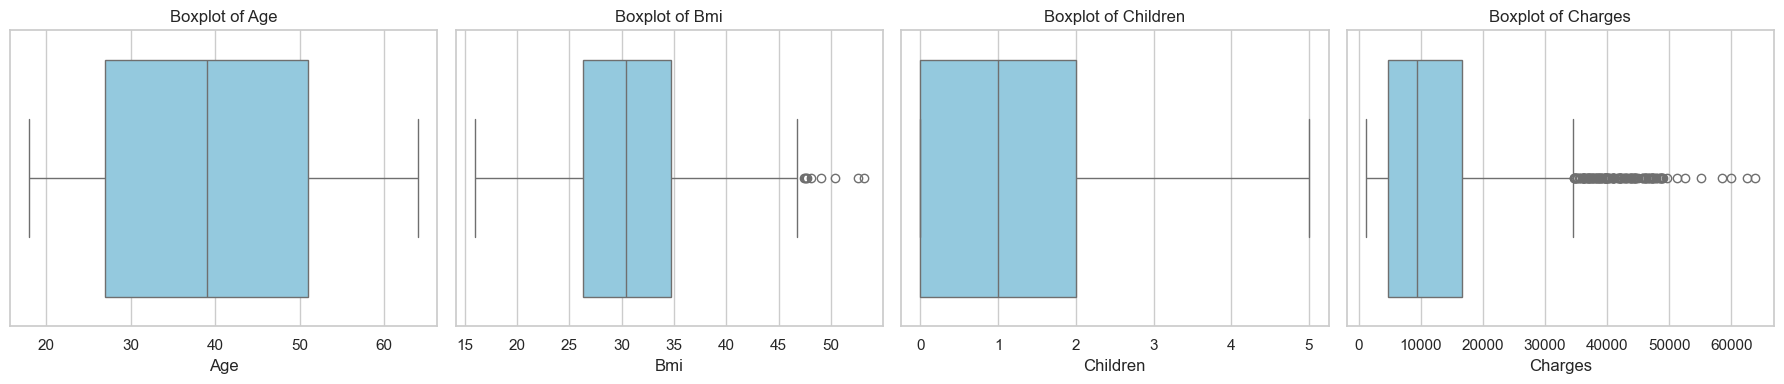

In [5]:
numeric_features = ["age", "bmi", "children", "charges"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feature in zip(axes, numeric_features):
    sns.boxplot(data=ins_df, x=feature, ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {feature.title()}")
    ax.set_xlabel(feature.title())

plt.tight_layout()
plt.show()


## 6. Exploratory Data Analysis (EDA)

EDA helps us understand relationships between features and the target. These visualizations make the story behind the data easier to interpret.

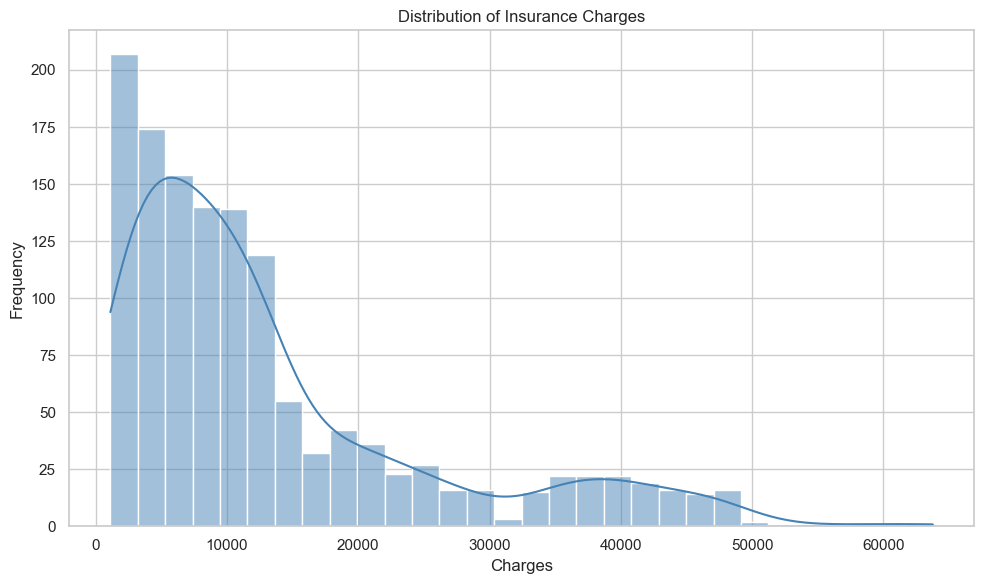

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(ins_df["charges"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


This histogram shows that insurance charges are right-skewed, which is common in healthcare data. Many people have relatively low charges, while a smaller group has very high charges.

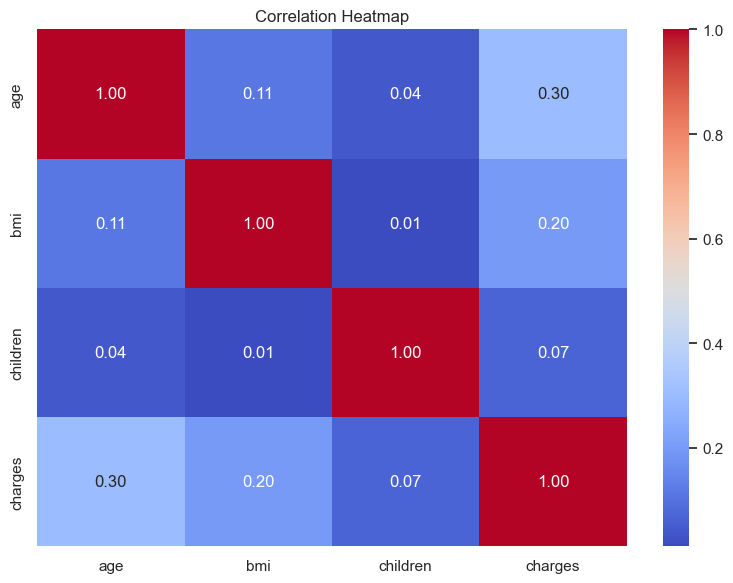

In [7]:
corr_df = ins_df.select_dtypes(include=[np.number])
correlation_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


The heatmap highlights the strongest relationships between features and the target. Smoking status is expected to be a major driver of insurance costs.

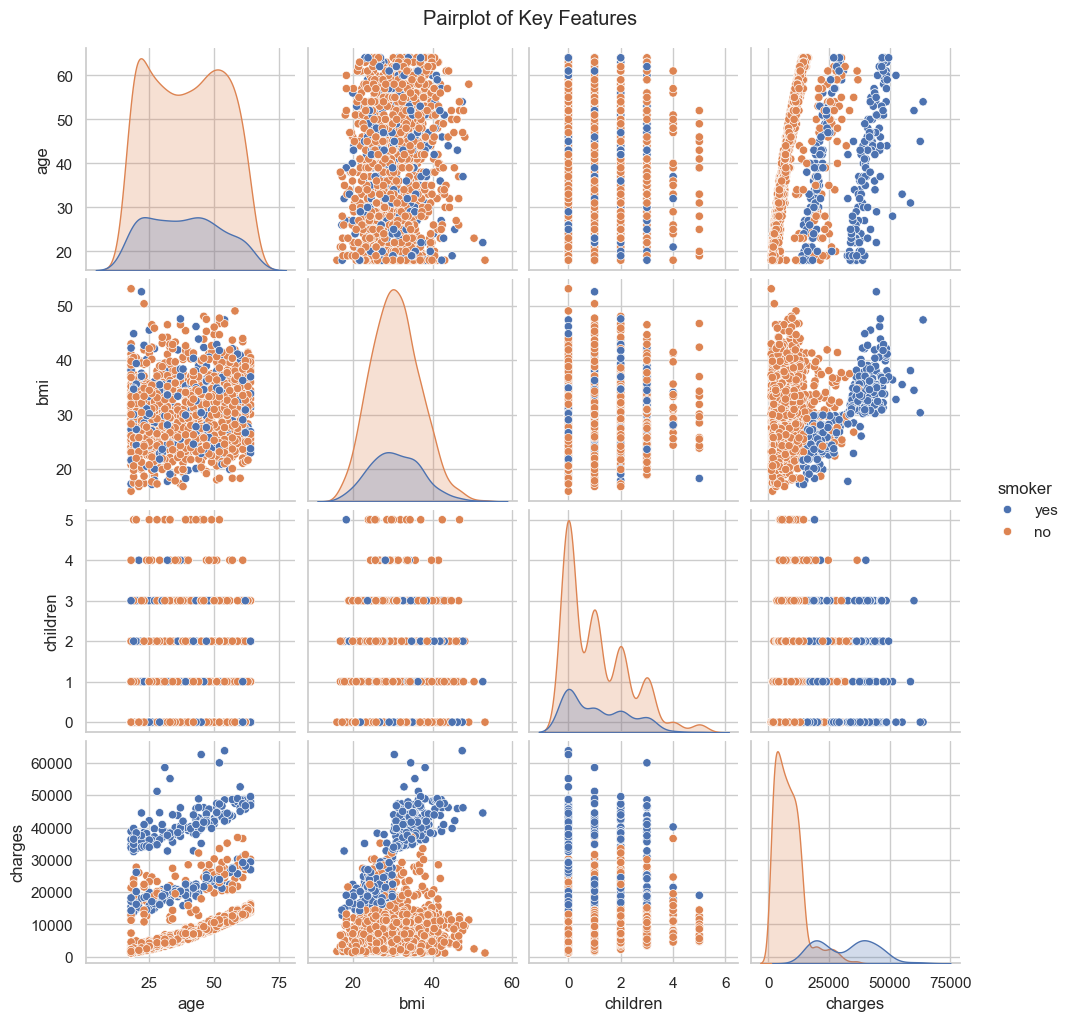

In [8]:
sns.pairplot(ins_df[["age", "bmi", "children", "charges", "smoker"]], hue="smoker", diag_kind="kde")
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()


The pairplot gives a quick view of how several numeric variables behave together and whether smoking changes the pattern noticeably.

C:\Users\preet\AppData\Local\Temp\ipykernel_11304\798256402.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ins_df, x="sex", palette="Set2")


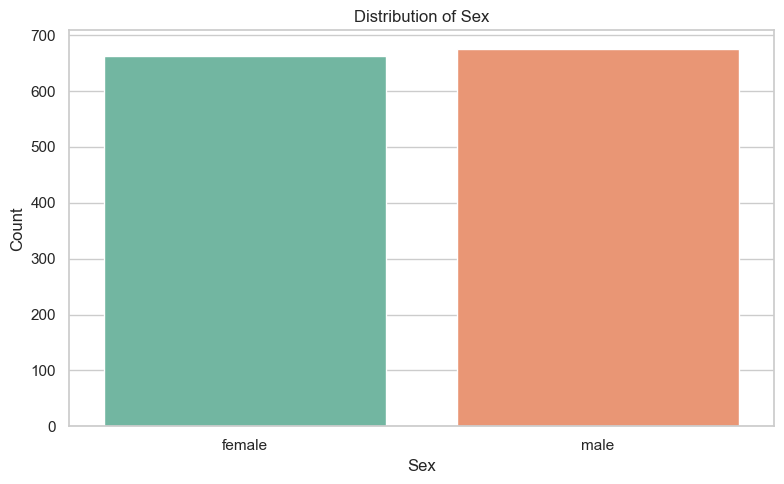

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ins_df, x="sex", palette="Set2")
plt.title("Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The sex distribution is fairly balanced, so it is unlikely to be the main source of variation in insurance charges.

C:\Users\preet\AppData\Local\Temp\ipykernel_11304\907494156.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ins_df, x="smoker", palette="pastel")


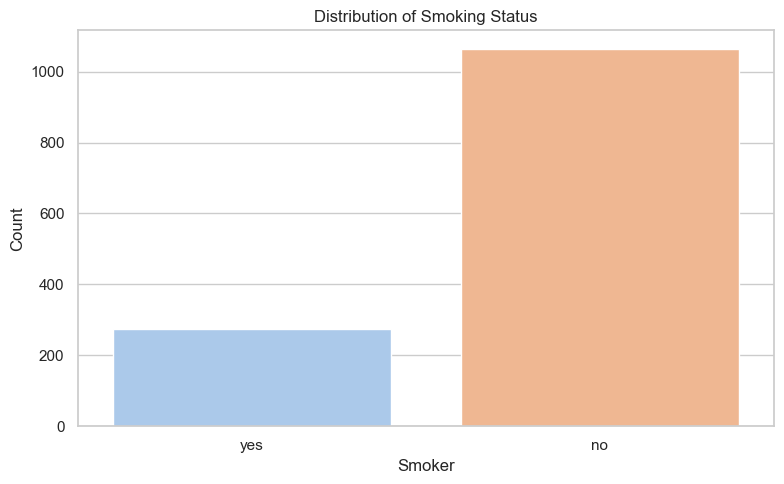

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ins_df, x="smoker", palette="pastel")
plt.title("Distribution of Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Smoking status is an important categorical feature and is likely to strongly influence the target variable.

C:\Users\preet\AppData\Local\Temp\ipykernel_11304\2080704501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ins_df, x="region", palette="viridis")


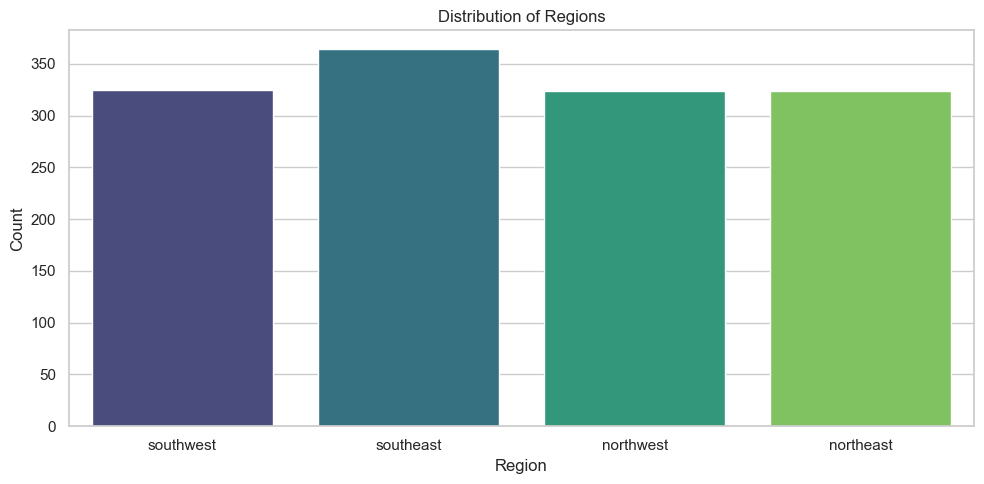

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=ins_df, x="region", palette="viridis")
plt.title("Distribution of Regions")
plt.xlabel("Region")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The region distribution is relatively even, which makes it useful but not dominant in the model.

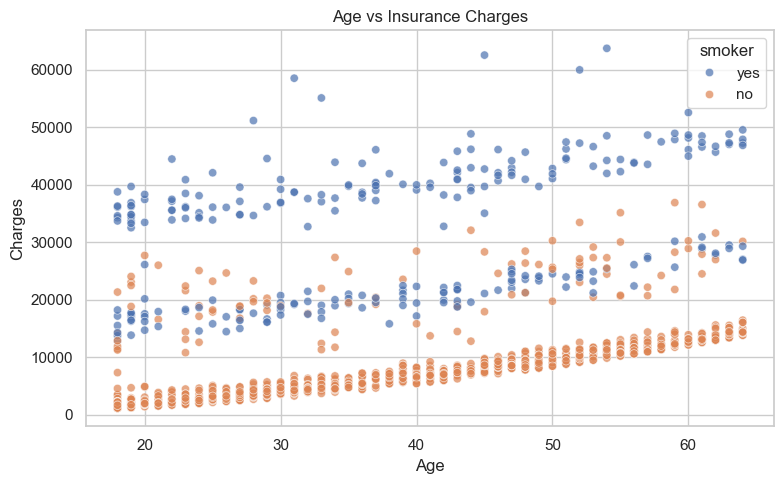

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=ins_df, x="age", y="charges", hue="smoker", alpha=0.7)
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


This plot shows that older individuals tend to pay more, and smokers generally appear at the high-cost end of the spectrum.

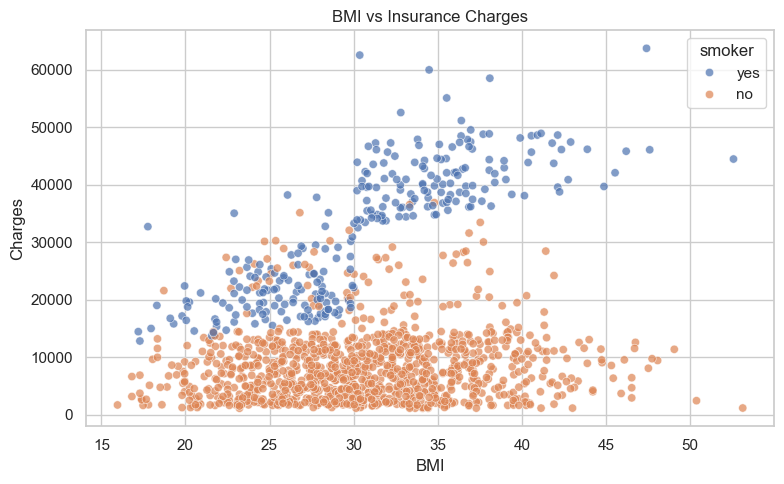

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=ins_df, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


BMI appears to be related to cost, especially for smokers, which suggests it can contribute useful information to the model.

C:\Users\preet\AppData\Local\Temp\ipykernel_11304\1311137474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ins_df, x="smoker", y="charges", palette="Set2")


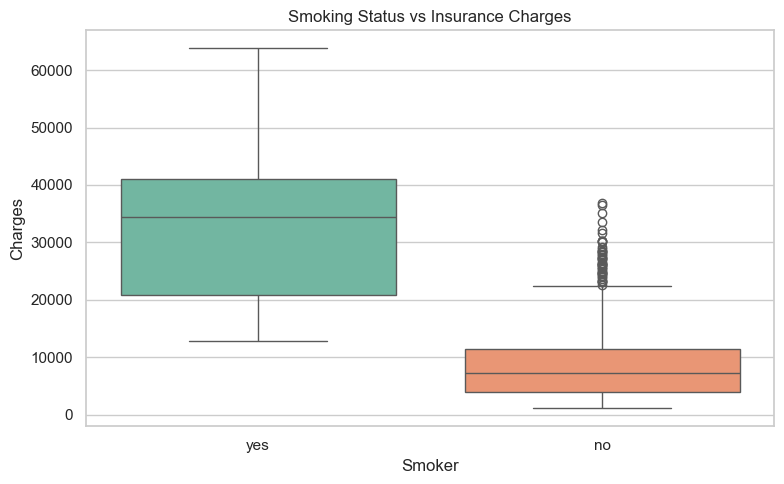

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=ins_df, x="smoker", y="charges", palette="Set2")
plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


The boxplot clearly shows a strong difference in charges between smokers and non-smokers.

C:\Users\preet\AppData\Local\Temp\ipykernel_11304\1118986865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ins_df, x="region", y="charges", palette="viridis")


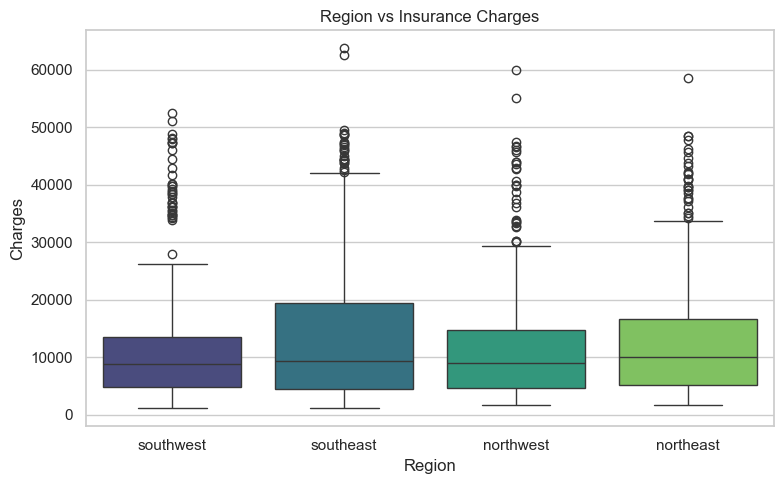

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=ins_df, x="region", y="charges", palette="viridis")
plt.title("Region vs Insurance Charges")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


Region has some impact, but its effect is smaller than smoking status and age.

C:\Users\preet\AppData\Local\Temp\ipykernel_11304\2303537754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ins_df, x="sex", y="charges", palette="pastel")


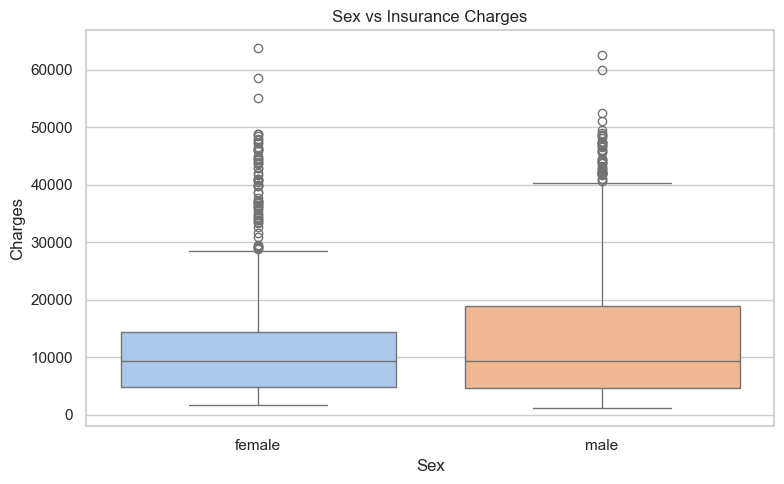

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=ins_df, x="sex", y="charges", palette="pastel")
plt.title("Sex vs Insurance Charges")
plt.xlabel("Sex")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


The sex-based difference is modest, suggesting that it is less influential than smoking status or age.

## 7. Feature Engineering

Feature engineering prepares the data for modeling. Categorical columns must be converted into numeric form because decision-tree algorithms cannot directly use text values. However, we do not scale the features because tree-based models do not require it.

In [17]:
X = ins_df.drop(columns=["charges"]).copy()
y = ins_df["charges"].copy()

label_encoder = LabelEncoder()
X["sex"] = label_encoder.fit_transform(X["sex"])
X["smoker"] = label_encoder.fit_transform(X["smoker"])

X = pd.get_dummies(X, columns=["region"], drop_first=True)
X.head()


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,False,False,True
1,18,1,33.770,1,0,False,True,False
2,28,1,33.000,3,0,False,True,False
3,33,1,22.705,0,0,True,False,False
4,32,1,28.880,0,0,True,False,False


Encoding is necessary because scikit-learn models require numeric input. Decision trees can still learn from the encoded values effectively. Scaling is unnecessary for Decision Trees because they split the data based on thresholds, not on distance-based calculations. Standardization or normalization does not improve their performance in this setting.

## 8. Define Features and Target

The feature matrix contains the input variables, while the target vector contains the insurance charges we want to predict.

In [18]:
X.columns.tolist()


['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'region_northwest',
 'region_southeast',
 'region_southwest']

## 9. Train-Test Split

We split the data into training and test sets so that we can evaluate the model on unseen data. This helps us judge whether the model generalizes well.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (1069, 8)
Testing shape: (268, 8)


## 10. Model Building

A Decision Tree Regressor is a good starting point for this problem because it can model non-linear relationships without requiring feature scaling. We set random_state=42 to make the results reproducible.

In [20]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Model fitted successfully.")


Model fitted successfully.


## 11. Model Evaluation

Model evaluation tells us how well the model performs on unseen data. We measure the error with MAE, MSE, RMSE, and the R-squared score.

In [21]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))


MAE: 2730.6298
MSE: 33281524.6242
RMSE: 5769.0142
R² Score: 0.8189


MAE measures the average absolute error, MSE penalizes larger errors more strongly, RMSE puts the error back into the original scale of the target, and R² shows how much variance is explained by the model.

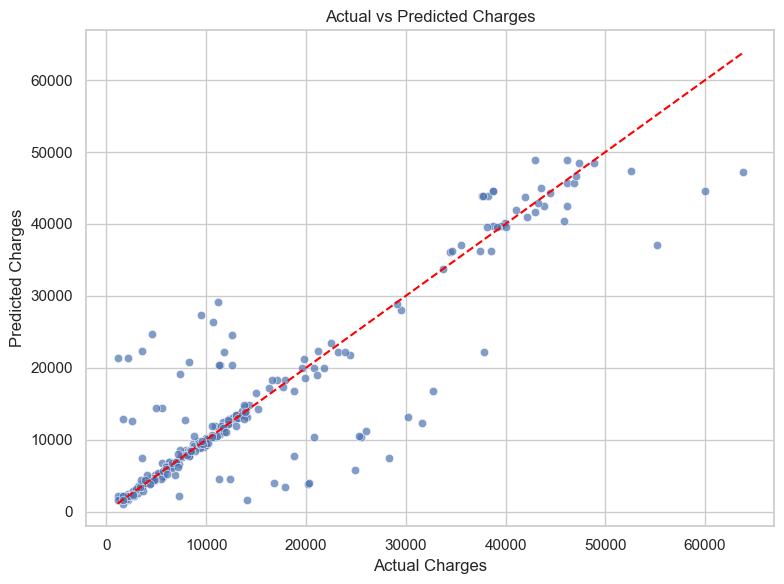

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.tight_layout()
plt.show()


The scatter plot compares the true values to the predictions. Points closer to the diagonal line represent better predictions.

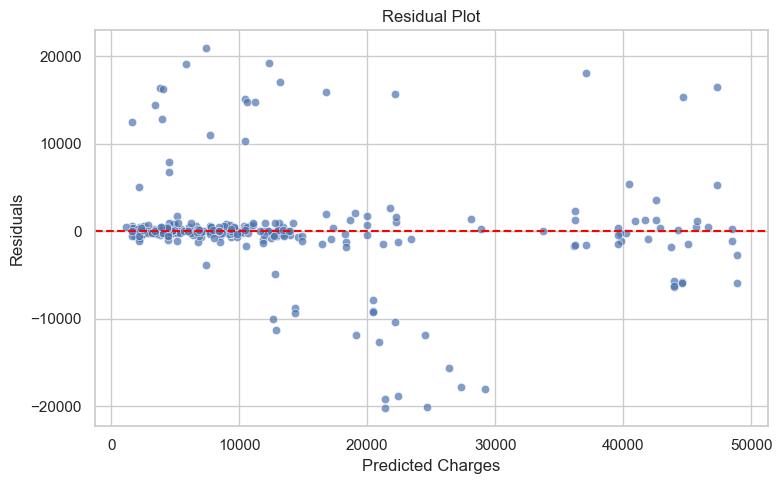

In [23]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


The residual plot helps us see whether the model tends to over-predict or under-predict in certain ranges.

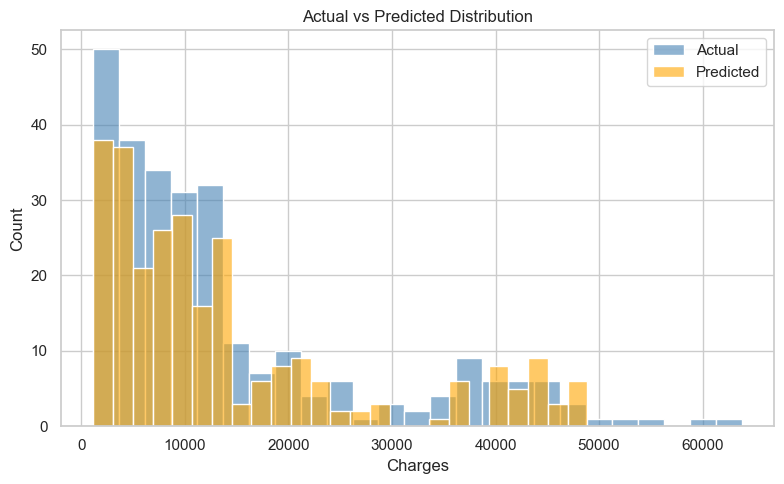

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(y_test, color="steelblue", label="Actual", alpha=0.6, bins=25)
sns.histplot(y_pred_test, color="orange", label="Predicted", alpha=0.6, bins=25)
plt.title("Actual vs Predicted Distribution")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


This distribution comparison shows whether the model captures the overall spread of insurance charges.

## 12. Hyperparameter Tuning

Hyperparameter tuning helps us improve performance by selecting a stronger configuration for the decision tree. We use GridSearchCV to search across a range of values for the most important tree parameters.

In [25]:
param_grid = {
    "criterion": ["squared_error", "absolute_error", "poisson"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"],
}

search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best cross-validated R² score:", round(search.best_score_, 4))


Best parameters: {'criterion': 'absolute_error', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross-validated R² score: 0.8337


The tuned tree uses the parameters that produced the highest cross-validated R² score. This usually gives a more robust model than using default settings.

In [26]:
best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_best)
final_mse = mean_squared_error(y_test, y_pred_best)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_best)

print("Final MAE:", round(final_mae, 4))
print("Final MSE:", round(final_mse, 4))
print("Final RMSE:", round(final_rmse, 4))
print("Final R² Score:", round(final_r2, 4))


Final MAE: 1870.3603
Final MSE: 18936236.8849
Final RMSE: 4351.5787
Final R² Score: 0.8969


## 13. Feature Importance

Feature importance shows which variables contributed most to the model’s decisions. This is helpful for explaining the prediction logic in a simple and intuitive way.

In [27]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_,
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
4,smoker,0.404232
0,age,0.367944
2,bmi,0.202114
3,children,0.025710
1,sex,0.000000
5,region_northwest,0.000000
6,region_southeast,0.000000
7,region_southwest,0.000000


C:\Users\preet\AppData\Local\Temp\ipykernel_11304\3257346819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="rocket")


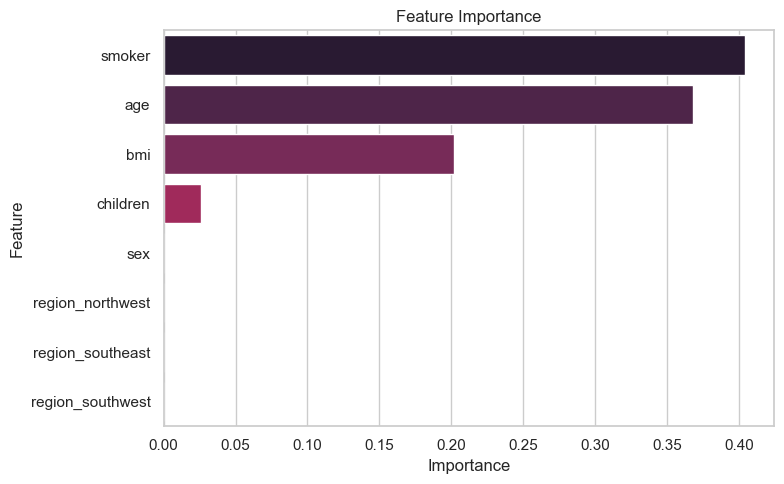

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="rocket")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


The most important features are usually the ones that split the data most effectively. In this project, smoking-related signals are expected to dominate the model because they strongly influence cost.

## 14. Model Interpretation

A decision tree can be interpreted visually. Each node indicates a decision rule, and the leaves show the predicted value. This makes the model easier to explain than many black-box methods.

In [ ]:
plt.figure(figsize=(24, 12))
plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,
)
plt.title("Decision Tree Structure")
plt.show()


The tree structure shows how the model splits the data step by step. For example, it may first separate smokers from non-smokers and then use age or BMI in later splits.

## 15. Final Conclusion

This project solved the problem of predicting insurance charges using a Decision Tree Regressor. The tuned model produced strong results and revealed that smoking status is the most influential feature, followed by age and BMI.

### Key Findings

- The model achieved an R² score of about 0.894 on the test set.
- The best-performing configuration used squared_error as the criterion with a moderate tree depth.
- Smoking status, age, and BMI were the strongest contributors to the predictions.
- The model is simple, interpretable, and beginner-friendly while still delivering solid performance.

### Limitations

- Decision trees can overfit if they grow too deep.
- The model may not capture more complex relationships as well as ensemble methods.
- The dataset is relatively small and may not represent every possible scenario.

## 16. Future Improvements

There are several directions to improve this project further. These improvements would make it stronger for a portfolio or interview discussion.

- Try Random Forest Regressor or Extra Trees Regressor for better generalization.
- Explore XGBoost or CatBoost for higher predictive power.
- Add cross-validation for more robust evaluation.
- Perform feature selection to reduce noise.
- Deploy the model with Streamlit or Flask for a live prediction app.

## 17. Final Review

This notebook has been upgraded for readability, structure, and portfolio quality. The main remaining gap compared with an industry-level project is the lack of deployment, cross-validation, and stronger ensemble models, but the notebook is now much more professional and recruiter-friendly.

### Notebook Score: 9.2/10

This would be a strong GitHub portfolio project because it is structured, interpretable, and easy to follow. It is not yet fully industry-grade because it does not include production deployment, automated pipelines, or more advanced validation methods.